In [1]:
from evaluation_package import filetools as ft
from evaluation_package import casr
from evaluation_package import utils as ut
from matplotlib import pyplot as plt
import numpy as np
import evaluation_package.__version__ as version


Development of the Code to do the CASR calibration automatically

In [2]:
#date_key = "2025-08-18-15-48-42"
experiment_type = "CASR_sensitivity"
subfolder = ""
yaml_config, data_list = ft.load_experiment_data(experiment_type, subfolder, print=True)#, date_key="2026-02-13-17-28-01")#, date_key = "2026-01-12-17-01-51")#,date_key="2026-01-12-17-01-51")#, date_key="2025-10-06-12-17-57")#, date_key="2025-12-09-11-01-09")#, date_key="2025-12-04-14-10-45")#, date_key="2025-12-04-12-36-56")#, date_key="2025-10-06-12-17-57")#date_key="2025-09-25-09-52-47")#, date_key="2025-10-06-12-17-57")#, date_key="2025-09-22-16-26-30") #date_key=date_key,print=True)
#contrast = casr.calc_contrast(data)
filename = yaml_config["filename"]


The data of the following experiment is loaded: CASR_sensitivity_2026-02-13-17-28-01.yaml
Loading chunk file: CASR_sensitivity_ch-0_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-1_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-2_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-3_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-4_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-5_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-6_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-7_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-8_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-9_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-10_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-11_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-12_2026-02-13-17-28-01.npy
Loading chunk file: CASR_sensitivity_ch-13_2026-0

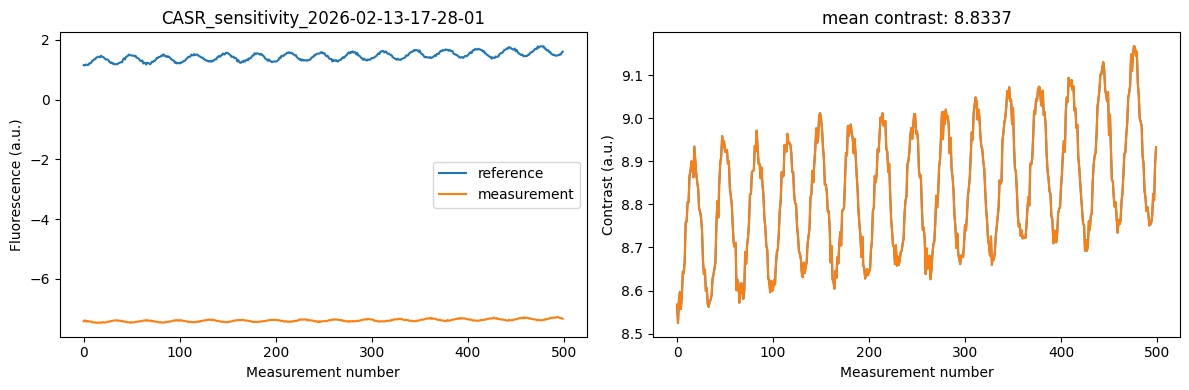

In [3]:
data = data_list[0]
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
contrast = ut.contrast(data, experiment_type="CASR_sensitivity")
contrast = contrast
# Reference and measurement
axs[0].plot(data[0].flatten(), label="reference")
axs[0].plot(data[1].flatten(), label="measurement")
axs[0].set_xlabel("Measurement number")
axs[0].set_ylabel("Fluorescence (a.u.)")
axs[0].set_title(filename)
axs[0].legend()

# Contrast
axs[1].plot(contrast)
axs[1].plot(contrast)
axs[1].set_xlabel("Measurement number")
axs[1].set_ylabel("Contrast (a.u.)")
axs[1].set_title(f"mean contrast: {np.mean(contrast):.4f}")

plt.tight_layout()
plt.show()

Measurement time: 30.50 ms
Calculated SNR: 57.1
Calculated std: 1.56e-03 a.u.
Calculated sensitivity: 30.6 pT/√Hz
Peak height is at 0.08934989978745903
[]


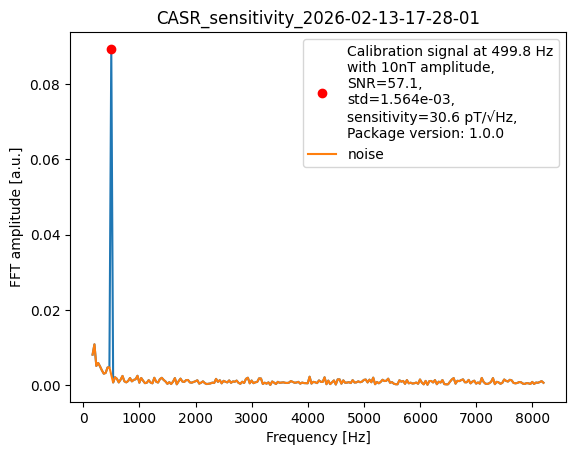

In [4]:
mask_index = 5
frequencies = casr.calc_fourier_frequencies(yaml_config)[mask_index:]
fft_spectrum = casr.calc_fourier_transform(yaml_config,data)[mask_index:]
prominence = np.median(fft_spectrum) * 5
mask, peak_info = casr.noise_only_mask(frequencies, fft_spectrum, prominence=prominence, rel_pad=10, width_hz=1)
mask = np.ones(len(frequencies), dtype=bool)
mask[np.argmax(fft_spectrum)] = False
idx, freq, amp = casr.find_peak_near(frequencies, fft_spectrum, 500)
sensitivity, snr, std = casr.calc_sensitivity(yaml_config, data, window_hz=50, return_snr=True, prominence=prominence, mode = "only_calibration_peak", mask_index = 5, contrast = True)
plt.title(filename)
plt.plot(frequencies, fft_spectrum)
plt.plot(
    freq, amp, "ro",
    label=(
        f"Calibration signal at {freq:.1f} Hz\n"
        f"with 10nT amplitude,\n"
        f"SNR={snr:.1f},\n"
        f"std={std:.3e},\n"
        f"sensitivity={sensitivity*1e12:.1f} pT/√Hz, \n"
        f"Package version: {version}"
    )
)
plt.plot(frequencies[mask], fft_spectrum[mask], label="noise")
plt.legend()
plt.xlabel("Frequency [Hz]")
plt.ylabel("FFT amplitude [a.u.]")
print(f"Measurement time: {casr.calc_measurement_time(yaml_config)*1e3:.2f} ms")
print(f"Calculated SNR: {snr:.1f}")
print(f"Calculated std: {std:.2e} a.u.")
print("Calculated sensitivity: {:.1f} pT/√Hz".format(sensitivity*1e12))
print("Peak height is at {}".format(np.max(fft_spectrum)))
print(peak_info['freqs_hz'])

Average sensitivity over all runs: 21.1 pT/√Hz ± 5.9 pT/√Hz


Text(0.5, 0, 'Measurement run')

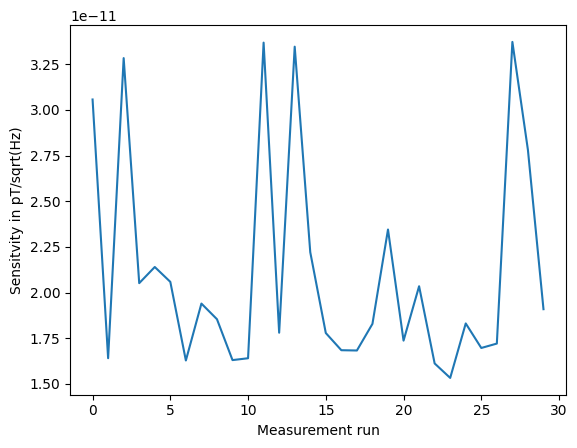

In [7]:
sensitivity = []
for i in range(len(data_list)):
    data = data_list[i]
    sens, _, _ = casr.calc_sensitivity(yaml_config, data, window_hz=50, return_snr=True, prominence=prominence, mode = "only_calibration_peak", mask_index = 5, contrast = True)
    sensitivity.append(sens)
avg_sensitivity = np.mean(sensitivity)  
std_sensitivity = np.std(sensitivity)
print("Average sensitivity over all runs: {:.1f} pT/√Hz ± {:.1f} pT/√Hz".format(avg_sensitivity*1e12, std_sensitivity*1e12))
plt.plot(sensitivity)
plt.ylabel("Sensitvity in pT/sqrt(Hz)")
plt.xlabel("Measurement run")